## Aufgabe 3.

Als Data Scientist haben Sie den Auftrag, in einer Firma herauszufinden, welche Mitarbeiter öfters
abwesend sind, wovon dies abhängt und wie man Absenzen voraussagen kann. Dazu erhalten Sie
den Datensatz employees.csv (Quelle: fiktiver Datensatz von kaggle.com), den Sie vorzugsweise
mittels Python analysieren.

(a) Daten sind oft nicht bereinigt. Die Firma sagt Ihnen, dass der Praktikant beim Erheben des
Datensatzes bestimmt ein paar Tippfehler gemacht hat. Ihnen wird auch gesagt, dass jeder
Mitarbeiter mindestens einmal gefehlt hat. Bereinigen Sie den Datensatz.

(b) Wovon hängen die Absenzen eher ab, von der Anzahl Jahren im Betrieb oder dem Alter der
Mitarbeiter? Führen Sie jeweils eine Regression durch.

(c) Plotten Sie die Residuen mittels Tukey-Anscombe Digrammen. Wie erklären Sie die scharfe
Kante im Residuenplot des Alters?

(d) Prüfen Sie, ob die Bedingungen der Residuenanalyse erfüllt sind.

(e) Berechnen und interpretieren Sie die R2 Werte für die beiden Fits.

(f) Was würden Sie der Firma raten?

### Aufgabe 3 (a)

In [147]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [148]:
df_employees = pd.read_csv("employees.csv", delimiter=",", header=0)

In [149]:
print(df_employees.shape)
df_employees.head()

(8336, 13)


,EmployeeNumber,Surname,GivenName,Gender,City,JobTitle,DepartmentName,StoreLocation,Division,Age,LengthService,AbsentHours,BusinessUnit
0,1,Gutierrez,Molly,F,Burnaby,Baker,Bakery,Burnaby,Stores,32.028816,6.018478,36.577306,Stores
1,2,Hardwick,Stephen,M,Courtenay,Baker,Bakery,Nanaimo,Stores,40.320902,5.532445,30.165072,Stores
2,3,Delgado,Chester,M,Richmond,Baker,Bakery,Richmond,Stores,48.822047,4.389973,83.807798,Stores
3,4,Simon,Irene,F,Victoria,Baker,Bakery,Victoria,Stores,44.599357,3.081736,70.020165,Stores
4,5,Delvalle,Edward,M,New Westminster,Baker,Bakery,New Westminster,Stores,35.697876,3.619091,0.000000,Stores


In [150]:
df_employees.describe()

,EmployeeNumber,Age,LengthService,AbsentHours
count,8336.000000,8336.000000,8336.000000,8336.000000
mean,4168.500000,42.007086,4.782910,61.283978
std,2406.540255,9.939798,2.462990,49.038365
min,1.000000,3.504743,0.012098,0.000000
25%,2084.750000,35.298748,3.575892,19.127590
50%,4168.500000,42.114924,4.600248,56.005808
75%,6252.250000,48.666943,5.623922,94.284692
max,8336.000000,77.938003,43.735239,272.530123


Die Variablen Age und AbsentHours sehen kritisch aus. Age sollte sicherlich nicht kleiner als 15 sein. Und AbsentHours sollten != 0 sein. Ich bereinige zuerst die AbsentHours ungleich 0. 

In [151]:
idx = np.where(df_employees['AbsentHours'] == 0) ## identifiziere alle zeilen, bei deinen AbsentHours = 0. 
df_employees_clean =df_employees.drop(idx[0]) ## lösche diese zeilen aus dem dataframe

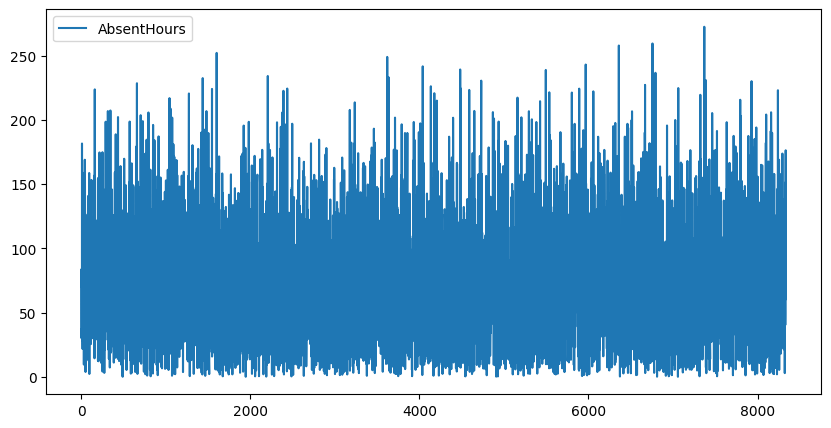

In [152]:
df_employees_clean[['AbsentHours']].plot(kind='line', figsize=(10, 5))
plt.show()

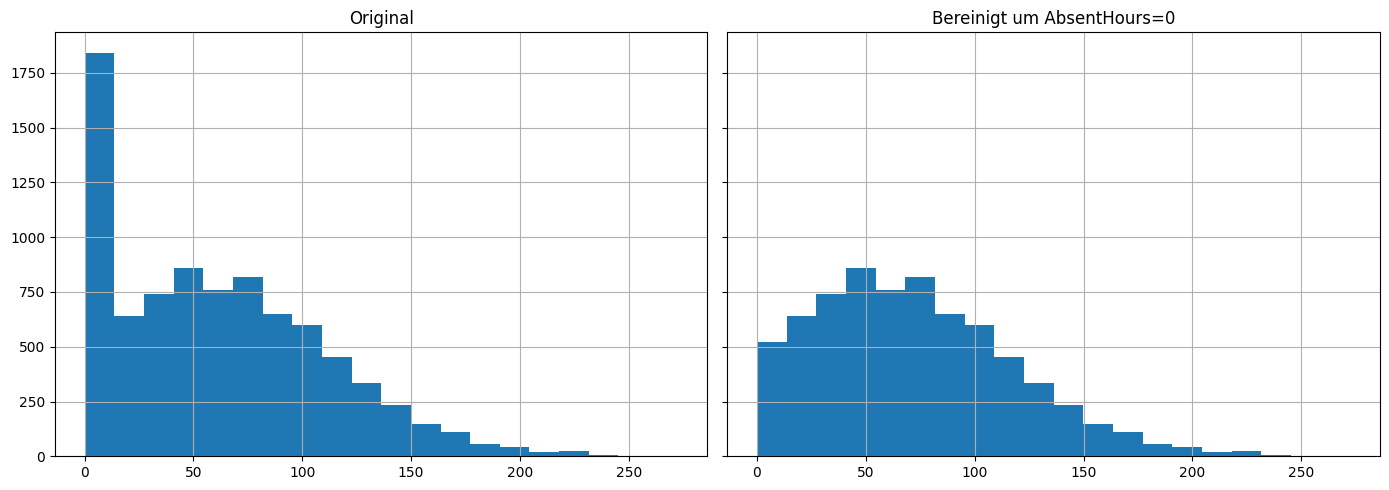

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

df_employees['AbsentHours'].hist(bins=20, ax=axes[0])
axes[0].set_title('Original')

df_employees_clean['AbsentHours'].hist(bins=20, ax=axes[1])
axes[1].set_title('Bereinigt um AbsentHours=0')

plt.tight_layout()
plt.show()


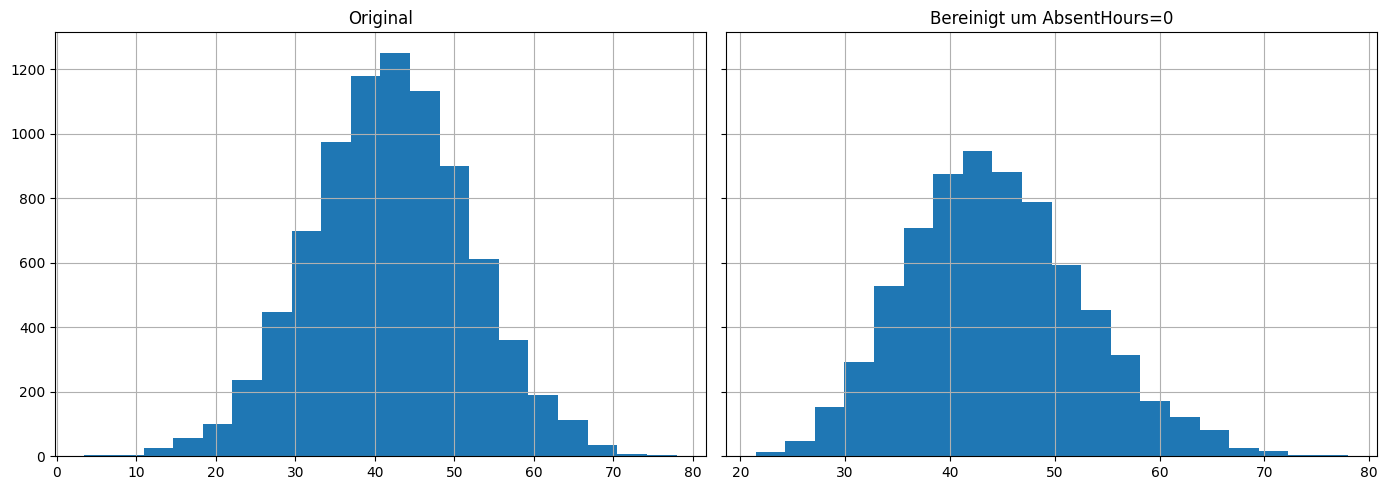

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

df_employees['Age'].hist(bins=20, ax=axes[0])
axes[0].set_title('Original')

df_employees_clean['Age'].hist(bins=20, ax=axes[1])
axes[1].set_title('Bereinigt um AbsentHours=0')

plt.tight_layout()
plt.show()

Scheint nichts weiter zu tun zu sein mit Age. Die bereits gelöschten Beobachtungen, beinhalteten die Age < 20. 

In [155]:
df_employees_clean.loc[df_employees_clean['AbsentHours'] == df_employees_clean['AbsentHours'].max()]

,EmployeeNumber,Surname,GivenName,Gender,City,JobTitle,DepartmentName,StoreLocation,Division,Age,LengthService,AbsentHours,BusinessUnit
7370,7371,Strickland,Kimberly,F,Kamloops,Shelf Stocker,Processed Foods,Kamloops,Stores,69.404369,6.677262,272.530123,Stores


### Aufgabe 3 (b)

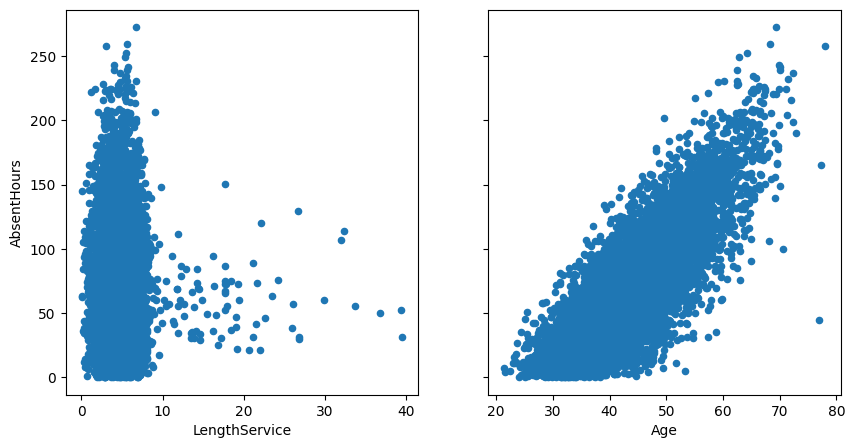

In [156]:
fig, axes = plt.subplots(1,2, figsize=(10,5), sharey=True)
df_employees_clean.plot(kind='scatter', x='LengthService', y='AbsentHours', ax=axes[0])
df_employees_clean.plot(kind='scatter', x='Age', y='AbsentHours', ax=axes[1])
plt.show()


Das scheint so, als gänge es eine positive Korrelation zwischen Age und AbsentHours.  

In [157]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [158]:
X = df_employees_clean[['Age']]          # doppelte Klammern: X muss 2D sein
y = df_employees_clean['AbsentHours']

model = LinearRegression().fit(X, y)

print("Achsenabschnitt:", model.intercept_)
print("Steigung:", model.coef_[0])
print("R²:", model.score(X, y))

Achsenabschnitt: -118.51170856780273
Steigung: 4.30605264550322
R²: 0.6493487820751211


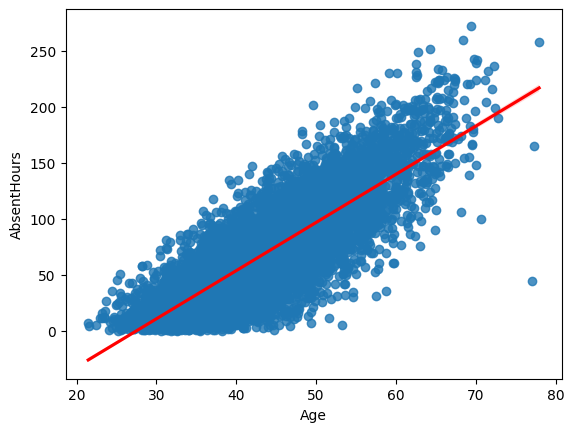

In [159]:
sns.regplot(x='Age', y='AbsentHours', data=df_employees_clean,
            line_kws={'color': 'red'})
plt.show()

### Aufgabe 3 (c) 

Wir brauchen das Tukey-Ascombe, um die Residuen über die geschätzten y-Werte zu visualisieren. Wir nehmen das berechnete Modell von oben "model" und predicten y^. Damit wir dann nachher die residuals über y_observed - y^berechnen können. 

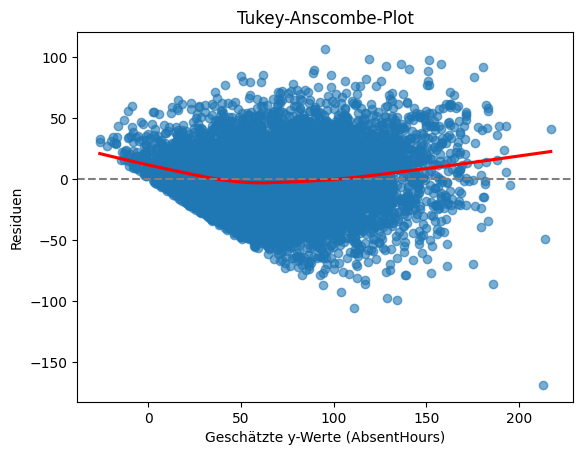

In [160]:
sns.regplot(x=y_pred, y=residuals, lowess=True,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('Geschätzte y-Werte (AbsentHours)')
plt.ylabel('Residuen')
plt.title('Tukey-Anscombe-Plot')
plt.show()

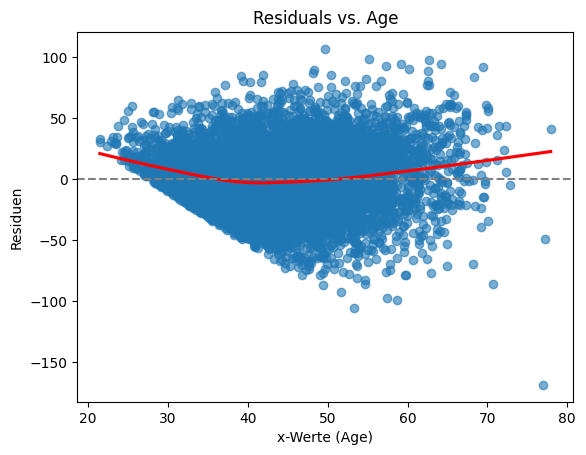

In [161]:
sns.regplot(x=X, y=residuals, lowess=True,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('x-Werte (Age)')
plt.ylabel('Residuen')
plt.title('Residuals vs. Age')
plt.show()

### Aufgabe 3 (d)

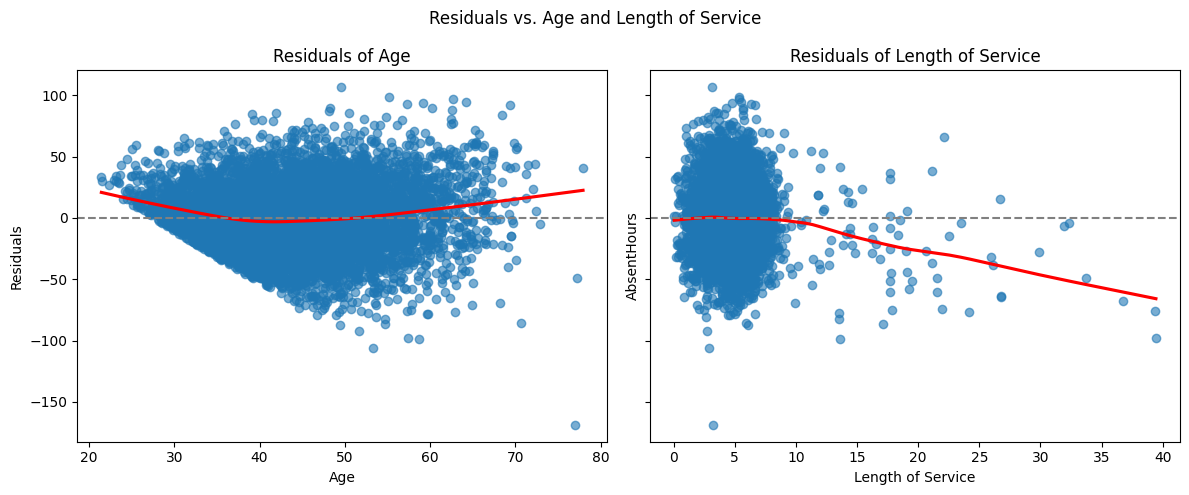

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
age = df_employees_clean['Age']
length_service = df_employees_clean['LengthService']

sns.regplot(x=age, y=residuals, lowess=True,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].axhline(0, color='grey', linestyle='--')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals of Age')

sns.regplot(x=length_service, y=residuals, lowess=True,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].axhline(0, color='grey', linestyle='--')
axes[1].set_xlabel('Length of Service')
axes[1].set_title('Residuals of Length of Service')

fig.suptitle('Residuals vs. Age and Length of Service')
plt.tight_layout()
plt.show()


Residuenanalyse (visuell) ergibt, dass Age und LengthofService beide nicht standardgemäss verhalten. Sie sehen so aus als hätten sie ein Muster. Daher sind die Residuen weder im Erwartungswert = 0, noch sind sie unabhängig. 

Schauen wir uns mal die Histogramme der Residuen an: 

In [164]:
age = df_employees_clean[['Age']]          # doppelte Klammern: X muss 2D sein
lengthService = df_employees_clean[['LengthService']]  # doppelte Klammern: X muss 2D sein
y = df_employees_clean['AbsentHours']

model_age = LinearRegression().fit(age, y)
model_loS = LinearRegression().fit(lengthService, y)
residuals_age = y - model_age.predict(df_employees_clean[['Age']])
residuals_loS= y - model_loS.predict(df_employees_clean[['LengthService']])

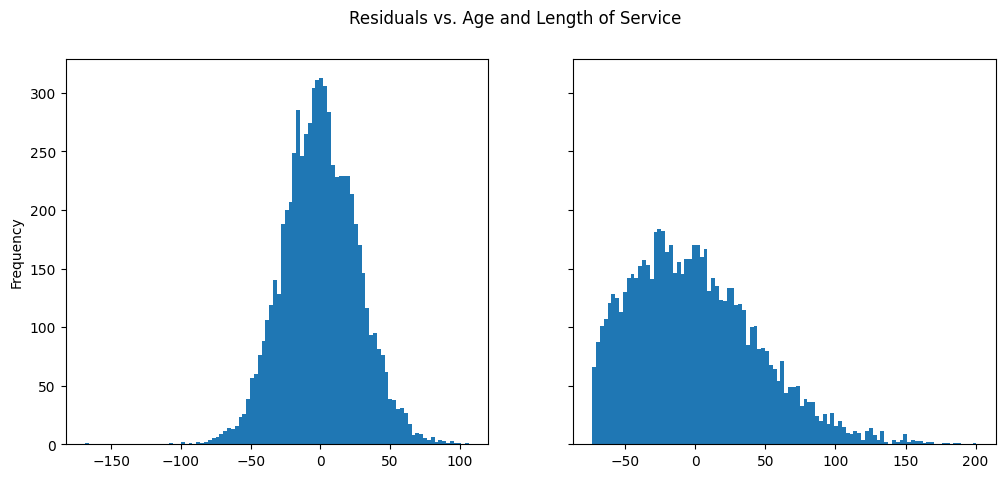

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

residuals_age.plot(kind="hist", bins=100, label='Age', ax=axes[0])
residuals_loS.plot(kind="hist", bins=100, label='Length of Service', ax=axes[1])
fig.suptitle('Residuals vs. Age and Length of Service')
plt.show()

Mit den Histogrammen sieht man jetzt ganz genau, dass die Residuen der Variablen Age noch als normalverteilt duchrgehen können. Aber die Residuen der Variable Length of Service ganz klar nicht mehr. Sie sind kurtotisch und rechtsschief.

### Aufgabe 3 (e) 
Wir haben bereits das R2 für Age. Wir müssen das noch rasch für Length of Service berechnen. 

In [ ]:
model_loS = LinearRegression().fit(lengthService, y)
metrics = {
    'Age': {
        'intercept': model_age.intercept_,
        'slope': model_age.coef_[0],
        'R²': model_age.score(age, y)
    },
    'Length of Service': {
        'intercept': model_loS.intercept_,              
        'slope': model_loS.coef_[0],
        'R²': model_loS.score(lengthService, y)
    }
}   
print(metrics)

{'Age': {'intercept': -118.51170856780273,
  'slope': 4.30605264550322,
  'R²': 0.6493487820751211},
 'Length of Service': {'intercept': 74.99104237763628,
  'slope': -0.4606517549454831,
  'R²': 0.0005010210095048873}}

R²': 0.0005010210095048873 --> unbrauchbar.